In [7]:
# Imports
import numpy as np
import pandas as pd
import pickle

t = 80

In [8]:
## k values
with open("N16_alpha_0.62_kis.pkl", "rb") as f:
    cherry_k_values = pickle.load(f)


## cherry m values
cherry_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'cherry/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)

## vanilla m values
vanilla_m_values = []
for i in range(10):
    m_values = np.load(f'vanilla/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [9]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
# cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100


cherry_reductions = []
for i in range(10):
    ch_red = []
    for k in range (t):
        ch_red.append(cherry_k_values[i] * cherry_m_values[i][k])
    cherry_reductions.append(np.sum(ch_red))

cherry_avg_reductions = np.mean(cherry_reductions)

# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_8800\774022504.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,1547.8,154727.2,1.915018e+08
1,vanilla,1539.6,396630.5,3.966305e+05


In [26]:
# calculate total cost of cherry and vanilla
cherry_avg_total_cost = cherry_avg_hashes + (cherry_avg_reductions * 1/577.3)
vanilla_avg_total_cost = vanilla_avg_hashes

print(f"Cherry total cost: {cherry_avg_total_cost}")
print(f"Vanilla total cost: {vanilla_avg_total_cost}")

Cherry total cost: 486446.8811430616
Vanilla total cost: 396630.5


C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_8800\1394871714.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bxplt = plt.boxplot([cherry_mt, vanilla_mt], labels=["Cherry-Picking", "Vanilla"], patch_artist=True)


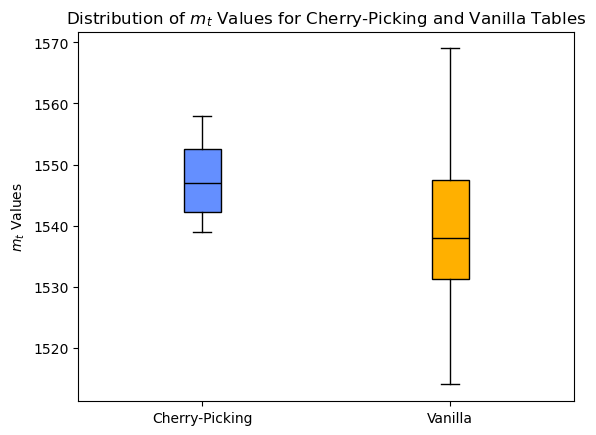

<Figure size 640x480 with 0 Axes>

In [24]:
# plot two boxplots to show the distribution of m_t values for cherry and vanilla
import matplotlib.pyplot as plt

cherry_mt = [cherry[-1] for cherry in cherry_m_values]
vanilla_mt = [vanilla[-1] for vanilla in vanilla_m_values]

clrs = ['#648fff', '#ffb000']

bxplt = plt.boxplot([cherry_mt, vanilla_mt], labels=["Cherry-Picking", "Vanilla"], patch_artist=True)
for patch, clr in zip(bxplt['boxes'], clrs):
    patch.set_facecolor(clr)

for median in bxplt['medians']:
    median.set(color='black')


plt.ylabel("$m_t$ Values")
plt.title("Distribution of $m_t$ Values for Cherry-Picking and Vanilla Tables")
plt.show()

# save as eps
plt.savefig("mt_boxplot.eps", format='eps')